## Data Loading

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df=pd.read_excel("../data/raw/Online Retail.xlsx")

## Data Inspection

In [4]:
display(df.head(5),df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


None

In [5]:
display(df.isna().sum(), df['Country'].value_counts())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


## Data Cleaning and Feature Engineering

In [6]:
df["TransactionValue"] = df["Quantity"] * df["UnitPrice"]

df = df.dropna(subset=['CustomerID']).copy()
df['Description'] = df['Description'].fillna('No description')

df["LogQuantity"] = np.sign(df["Quantity"]) * np.log1p(df["Quantity"].abs())
df["LogTransactionValue"] = np.sign(df["TransactionValue"]) * np.log1p(df["TransactionValue"].abs())
df["LogUnitPrice"] = np.sign(df["UnitPrice"]) * np.log1p(df["UnitPrice"].abs())

sales = df[df['Quantity'] > 0].copy()
returns = df[df['Quantity'] < 0].copy()



In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   InvoiceNo            406829 non-null  object        
 1   StockCode            406829 non-null  object        
 2   Description          406829 non-null  object        
 3   Quantity             406829 non-null  int64         
 4   InvoiceDate          406829 non-null  datetime64[us]
 5   UnitPrice            406829 non-null  float64       
 6   CustomerID           406829 non-null  float64       
 7   Country              406829 non-null  str           
 8   TransactionValue     406829 non-null  float64       
 9   LogQuantity          406829 non-null  float64       
 10  LogTransactionValue  406829 non-null  float64       
 11  LogUnitPrice         406829 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(1), object(3), str(1)
memory usage: 45.5+ MB


## Product and Country analysis

- Some analysis are represented as a top 6 due to the heavy influence of the United kingdom on them, as the UK lead by a significantly large margin
- The log transformed values created earlier are kept for EDA

In [5]:
# ==============================
# PRODUCT & COUNTRY ANALYSIS
# ==============================

# Top countries by sales revenue
top_countries_sales = (
    sales.groupby("Country")["TransactionValue"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
)

print("TOP 6 COUNTRIES BY SALES AMOUNT")
display(top_countries_sales)


# Top countries by returned quantity
top_countries_returns = (
    returns.groupby("Country")["Quantity"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
    .head(6)
)

print("TOP 6 COUNTRIES BY RETURNED QUANTITY")
display(top_countries_returns)


# Most frequently purchased products
most_bought_by_freq = (
    sales.groupby("Description")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)

print("MOST FREQUENTLY PURCHASED PRODUCTS")
display(most_bought_by_freq)


# Most purchased products by quantity
most_bought_by_qty = (
    sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("MOST PURCHASED PRODUCTS BY QUANTITY")
display(most_bought_by_qty)


# Most returned products by quantity
most_returned_by_qty = (
    returns.groupby("Description")["Quantity"]
    .apply(lambda x: x.abs().sum())
    .sort_values(ascending=False)
    .head(6)
)

print("MOST RETURNED PRODUCTS BY QUANTITY")
display(most_returned_by_qty)


# Most returned products by frequency
most_returned_by_freq = (
    returns.groupby("Description")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)

print("MOST FREQUENTLY RETURNED PRODUCTS")
display(most_returned_by_freq)

TOP 6 COUNTRIES BY SALES AMOUNT


Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Name: TransactionValue, dtype: float64

TOP 6 COUNTRIES BY RETURNED QUANTITY


Country
United Kingdom    260939
EIRE                4196
Germany             1815
France              1624
USA                 1424
Spain               1127
Name: Quantity, dtype: int64

MOST FREQUENTLY PURCHASED PRODUCTS


Description
WHITE HANGING HEART T-LIGHT HOLDER    1971
REGENCY CAKESTAND 3 TIER              1704
JUMBO BAG RED RETROSPOT               1600
PARTY BUNTING                         1380
ASSORTED COLOUR BIRD ORNAMENT         1375
Name: InvoiceNo, dtype: int64

MOST PURCHASED PRODUCTS BY QUANTITY


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
Name: Quantity, dtype: int64

MOST RETURNED PRODUCTS BY QUANTITY


Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9367
Manual                                  3995
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
PINK BLUE FELT CRAFT TRINKET BOX        2617
Name: Quantity, dtype: int64

MOST FREQUENTLY RETURNED PRODUCTS


Description
REGENCY CAKESTAND 3 TIER             180
Manual                               154
POSTAGE                               95
JAM MAKING SET WITH JARS              86
SET OF 3 CAKE TINS PANTRY DESIGN      72
Name: InvoiceNo, dtype: int64

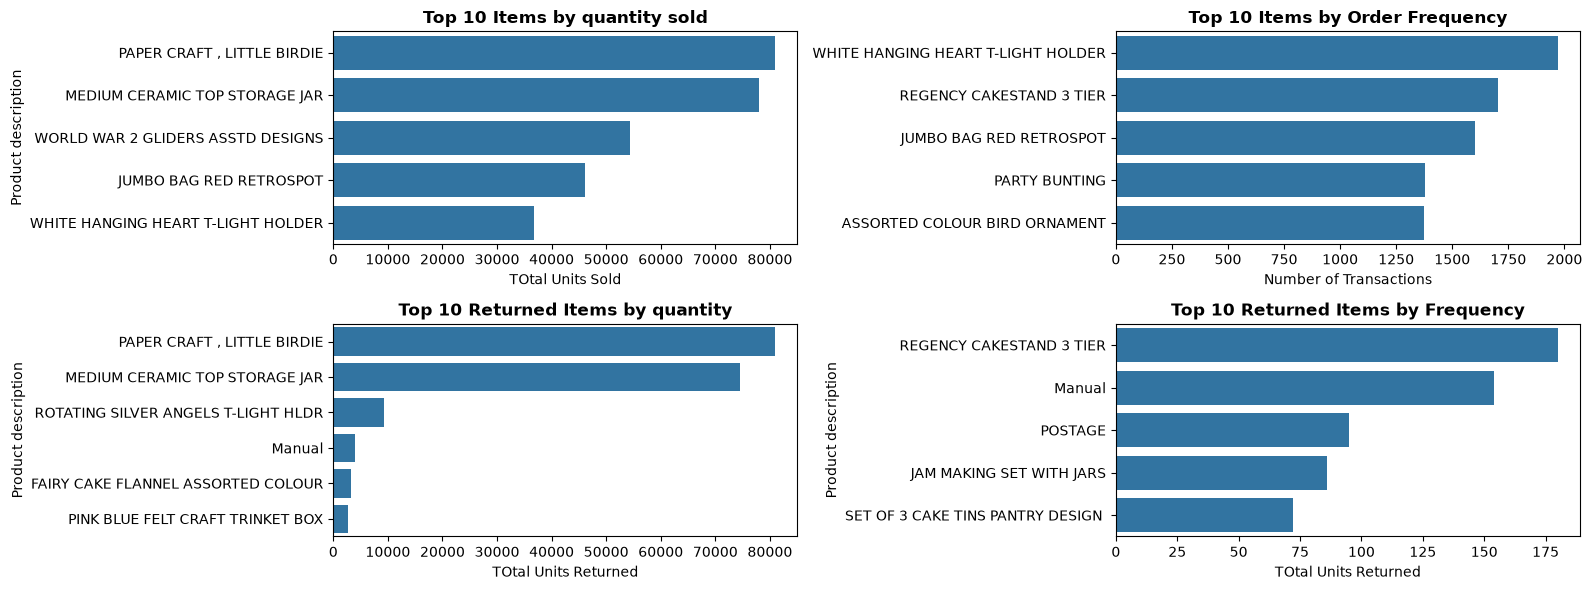

In [6]:
fig, axes = plt.subplots(2,2, figsize=(16,6))
ax1,ax2,ax3,ax4= axes.flatten()

sns.barplot(data=most_bought_by_qty.head(10).reset_index(), 
            x="Quantity", 
            y='Description', 
            ax=ax1)
ax1.set_title("Top 10 Items by quantity sold", fontsize=12, fontweight='bold')
ax1.set_xlabel("TOtal Units Sold")
ax1.set_ylabel('Product description')

sns.barplot(
    data=most_bought_by_freq.head(10).reset_index(),
    x="InvoiceNo",
    y="Description",
    ax=ax2
)
ax2.set_title("Top 10 Items by Order Frequency", fontsize=12, fontweight='bold')
ax2.set_xlabel("Number of Transactions")
ax2.set_ylabel("")

sns.barplot(data=most_returned_by_qty.head(10).reset_index(), 
            x="Quantity", 
            y='Description', 
            ax=ax3)
ax3.set_title("Top 10 Returned Items by quantity", fontsize=12, fontweight='bold')
ax3.set_xlabel("TOtal Units Returned")
ax3.set_ylabel('Product description')

sns.barplot(data=most_returned_by_freq.head(10).reset_index(), 
            x="InvoiceNo", 
            y='Description', 
            ax=ax4)
ax4.set_title("Top 10 Returned Items by Frequency", fontsize=12, fontweight='bold')
ax4.set_xlabel("TOtal Units Returned")
ax4.set_ylabel('Product description')


plt.tight_layout()
plt.show()

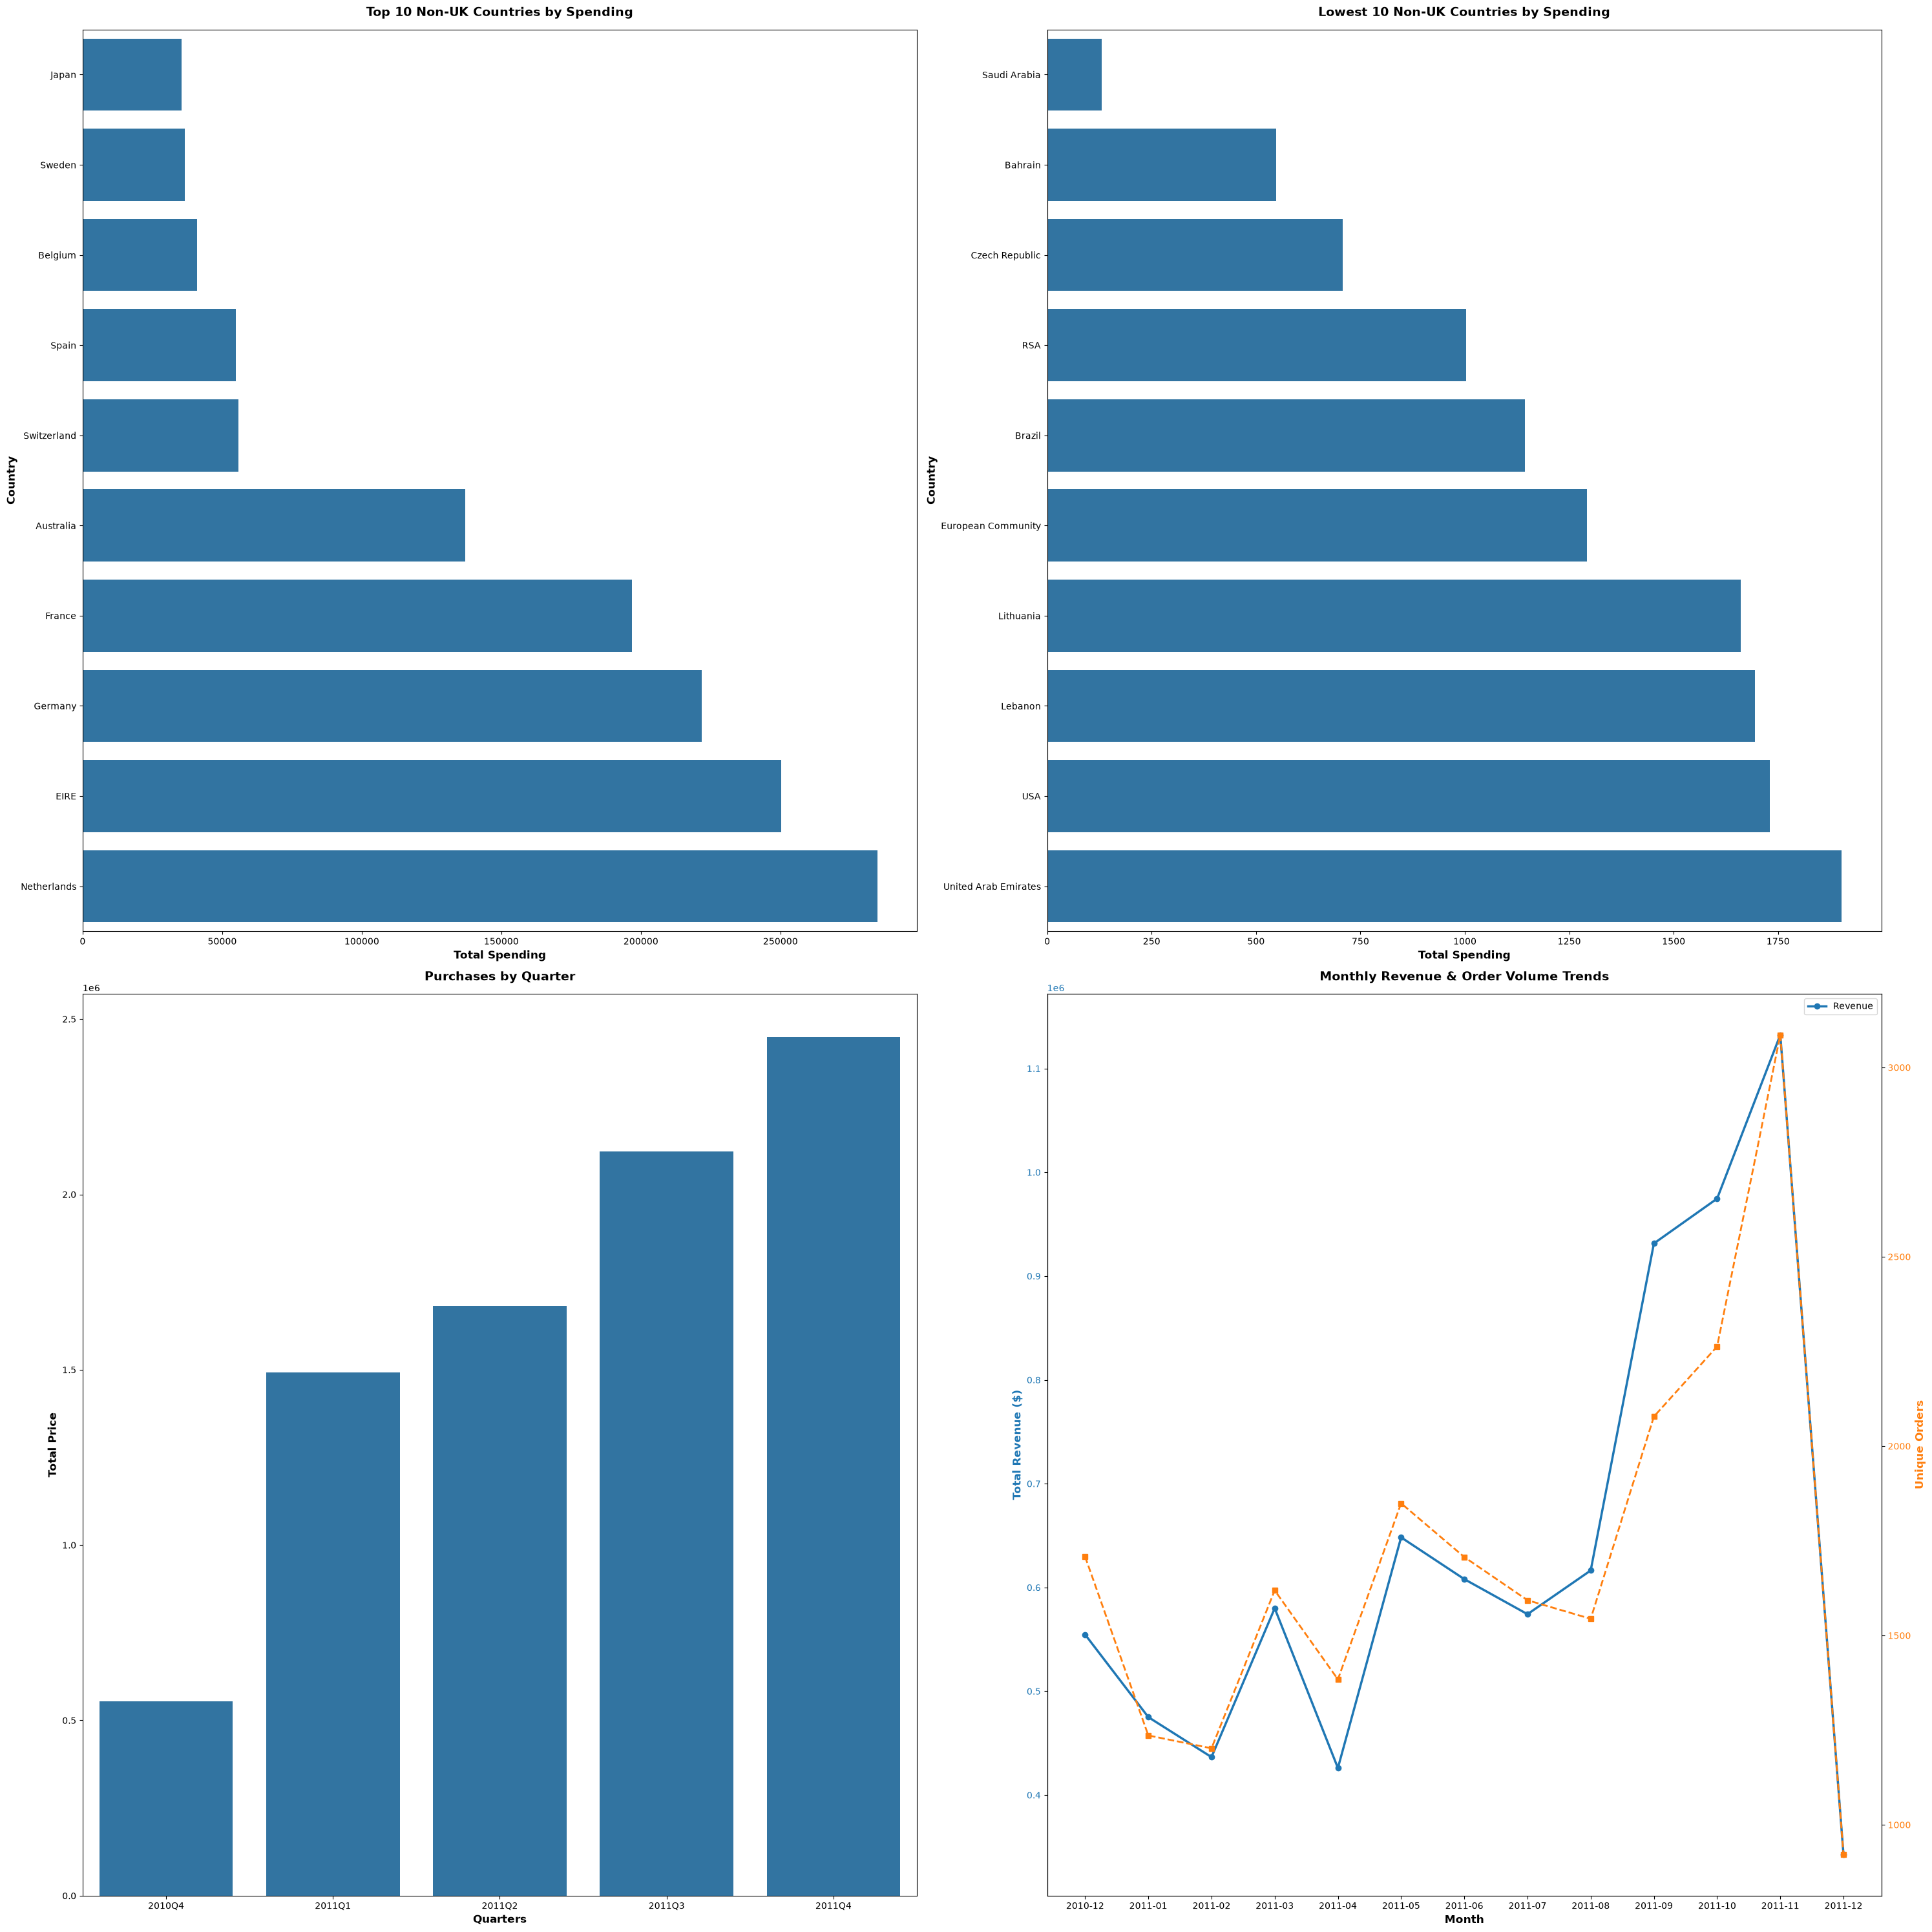

In [7]:
fig, axes = plt.subplots(2,2, figsize=(30,30))
ax1,ax2,ax3,ax4 = axes.flatten()

def plot_country_spending(df, ax, n=10, ascending=False, log_scale=False):
    spend_df = (
        df[(df["Country"] != "United Kingdom")]
        .groupby("Country")["TransactionValue"]
        .sum()
        .sort_values(ascending=ascending)
        .head(n)
        .reset_index()
    )

    spend_df = spend_df.sort_values(by="TransactionValue", ascending=True)

    spend_df["Country"] = spend_df["Country"].astype(str)
    
    sns.barplot(data=spend_df, x="TransactionValue", y="Country",ax=ax)

    label_type = "Lowest" if ascending else "Top"
    ax.set_title(f"{label_type} {n} Non-UK Countries by Spending", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Total Spending",fontsize=12, fontweight='bold')
    ax.set_ylabel("Country",fontsize=12, fontweight='bold')
    #ax.tick_params(axis="x", rotation=90)

    if log_scale:
        ax.set_xscale("log")

    return ax
plot_country_spending(df,ax1)
plot_country_spending(df, ax2, ascending=True)

Quarters = (
    df.groupby(df['InvoiceDate'].dt.to_period('Q'))
    .agg(TotalRevenue = ('TransactionValue', 'sum'),
        OrderCount=('InvoiceNo', 'nunique'))
    .reset_index()
        )
        

sns.barplot(
   data=Quarters,
   x='InvoiceDate',
   y='TotalRevenue',
   ax=ax3
)
ax3.set_title("Purchases by Quarter", fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Quarters",fontsize=12, fontweight='bold')
ax3.set_ylabel("Total Price",fontsize=12, fontweight='bold')



color1='#1f77b4'
color2='#ff7f0e'
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310

monthly_data = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
    .agg(
        TotalRevenue=('TransactionValue', 'sum'),
        OrderCount=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

ax4.set_xlabel('Month', fontsize=12, fontweight='bold')
ax4.set_ylabel('Total Revenue ($)', color=color1, fontsize=12, fontweight='bold')
ax4.plot(monthly_data['InvoiceDate'].astype('str'), monthly_data['TotalRevenue'], 
        color=color1, marker='o', linewidth=2.5, label='Revenue')
ax4.tick_params(axis='y', labelcolor=color1)
# Dual Axis for Ordert Count (Line 2)
ax4_twin = ax4.twinx()  
ax4_twin.set_ylabel('Unique Orders', color=color2, fontsize=12, fontweight='bold')
ax4_twin.plot(monthly_data['InvoiceDate'].astype('str'), monthly_data['OrderCount'], 
             color=color2, marker='s', linestyle='--', linewidth=2, label='Orders')
ax4_twin.tick_params(axis='y', labelcolor=color2)

ax4.set_title('Monthly Revenue & Order Volume Trends', fontsize=14, fontweight='bold', pad=15)
ax4.legend()


plt.tight_layout()
plt.show()

In [8]:
print("\n NET SPEND BY COUNTRY")
display(df.groupby('Country')['TransactionValue']
    .agg(['sum','mean','median','min','max','std'])
    .round(2)
    .sort_values(by='sum', ascending= False))

print("\n NET INCOME BY QUATERS")
display(Quarters)
    



 NET SPEND BY COUNTRY


,sum,mean,median,min,max,std
Country,,,,,,
United Kingdom,6767873.39,18.70,10.20,-168469.60,168469.60,451.92
Netherlands,284661.54,120.06,91.80,-266.40,4992.00,164.28
EIRE,250285.22,33.44,17.34,-1687.17,2365.20,91.45
Germany,221698.21,23.35,16.60,-599.50,876.00,37.32
France,196712.84,23.17,16.50,-8322.12,4161.06,117.63
Australia,137077.27,108.88,51.84,-425.00,1718.40,159.01
Switzerland,55739.40,29.70,17.70,-179.00,360.00,36.50
Spain,54774.58,21.62,15.00,-1715.85,1350.00,83.93
Belgium,40910.96,19.77,16.60,-19.95,165.00,15.58



 NET INCOME BY QUATERS


,InvoiceDate,TotalRevenue,OrderCount
0,2010Q4,554604.020,1708
1,2011Q1,1491585.140,4057
2,2011Q2,1682312.091,4940
3,2011Q3,2122046.853,5215
4,2011Q4,2449517.710,6270


## Exploratory Data Analysis


### Summary Analysis

In [9]:
numeric_cols = [col for col in df.select_dtypes(include='number').columns
                if col != 'CustomerID']
desc = df[numeric_cols].describe().T
desc['variance'] = df[numeric_cols].var()
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
desc['cv'] = desc['std']/desc['mean']
display(desc.round(3))

,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,cv
Quantity,406829.0,12.061,248.693,-80995.000,2.000,5.000,12.000,80995.000,61848.392,0.183,94317.564,20.619
UnitPrice,406829.0,3.460,69.315,0.000,1.250,1.950,3.750,38970.000,4804.592,452.219,246924.543,20.031
TransactionValue,406829.0,20.402,427.592,-168469.600,4.200,11.100,19.500,168469.600,182834.677,-0.057,124024.422,20.958
LogQuantity,406829.0,1.843,1.121,-11.302,1.099,1.792,2.565,11.302,1.257,-0.058,2.938,0.608
LogTransactionValue,406829.0,2.349,1.243,-12.035,1.649,2.493,3.020,12.035,1.544,-1.044,5.568,0.529
LogUnitPrice,406829.0,1.162,0.611,0.000,0.811,1.082,1.558,10.571,0.373,1.074,3.439,0.526


### Data Visualization

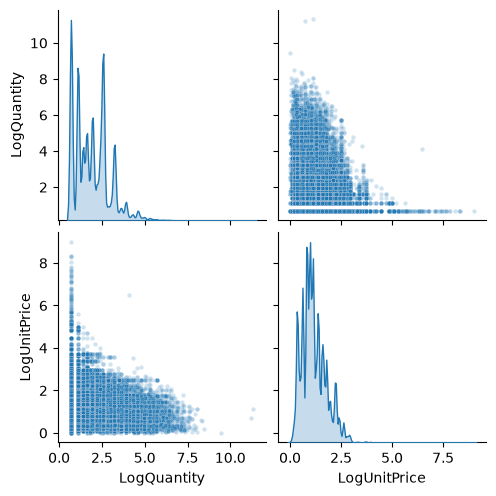

In [10]:

sns.pairplot(
    sales[['LogQuantity','LogUnitPrice']],
    kind = 'scatter',
    diag_kind='kde',
    plot_kws={'alpha':0.2, 's':10}
)
plt.show()



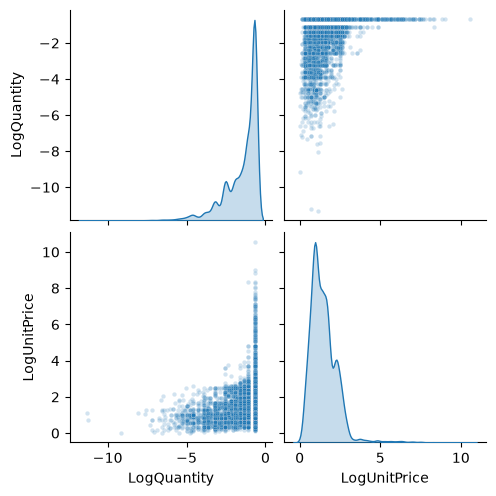

In [11]:
sns.pairplot(
    returns[['LogQuantity','LogUnitPrice']],
    kind='scatter',
    diag_kind='kde',
    plot_kws={'alpha':0.2, 's':10}
)
plt.show()

## RFM Analysis

In [12]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date-x.max()).days,
    'InvoiceNo': 'nunique',
    'TransactionValue':'sum'
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

#Recency -> Lower is better
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
#Frequency
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
#Monetary -> Higher is better
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])


#Combined RFM Score string
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# Define Customer Segments based on R and F scores
def segment_customer(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])
    m = int(df['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif m >= 4 and f >= 4:
        return 'Loyal High-value Customers'
    elif r >= 4 and f == 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m>=4:
        return 'At Risk High Value'
    elif r<=2 and f>=4 and m<=2:
        return 'At risk low-value'
    elif r<=2 and f<=2:
        return 'Lost'
    else:
        return 'Hibernating / Average'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Segment Summary Table
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).reset_index()

total_rev = rfm['Monetary'].sum()
total_cust = rfm['CustomerID'].count()

segment_summary['Customer_Pct'] = (segment_summary['Customer_Count'] / total_cust) * 100
segment_summary['Revenue_Pct'] = (segment_summary['Total_Revenue'] / total_rev) * 100
segment_summary = segment_summary.sort_values(by='Total_Revenue', ascending=False)

print("=== RFM Segment Summary ===")
print(segment_summary.to_string(index=False))



=== RFM Segment Summary ===
                   Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Customer_Pct  Revenue_Pct
                 Champions             976    11.976434      13.351434   5790.923648    5651941.480     22.323879    68.095141
Loyal High-value Customers             420    81.919048       7.176190   2607.623619    1095201.920      9.606587    13.195099
     Hibernating / Average            1493    69.879437       2.458138    513.566981     766755.502     34.149131     9.237945
                      Lost            1058   216.993384       1.202268    376.314112     398140.331     24.199451     4.796833
       Potential Loyalists             306    15.702614       2.594771    815.301601     249482.290      6.999085     3.005787
        At Risk High Value              80   137.687500       2.762500   1583.590137     126687.211      1.829826     1.526340
         At risk low-value              39   169.384615       4.820513    304.02769

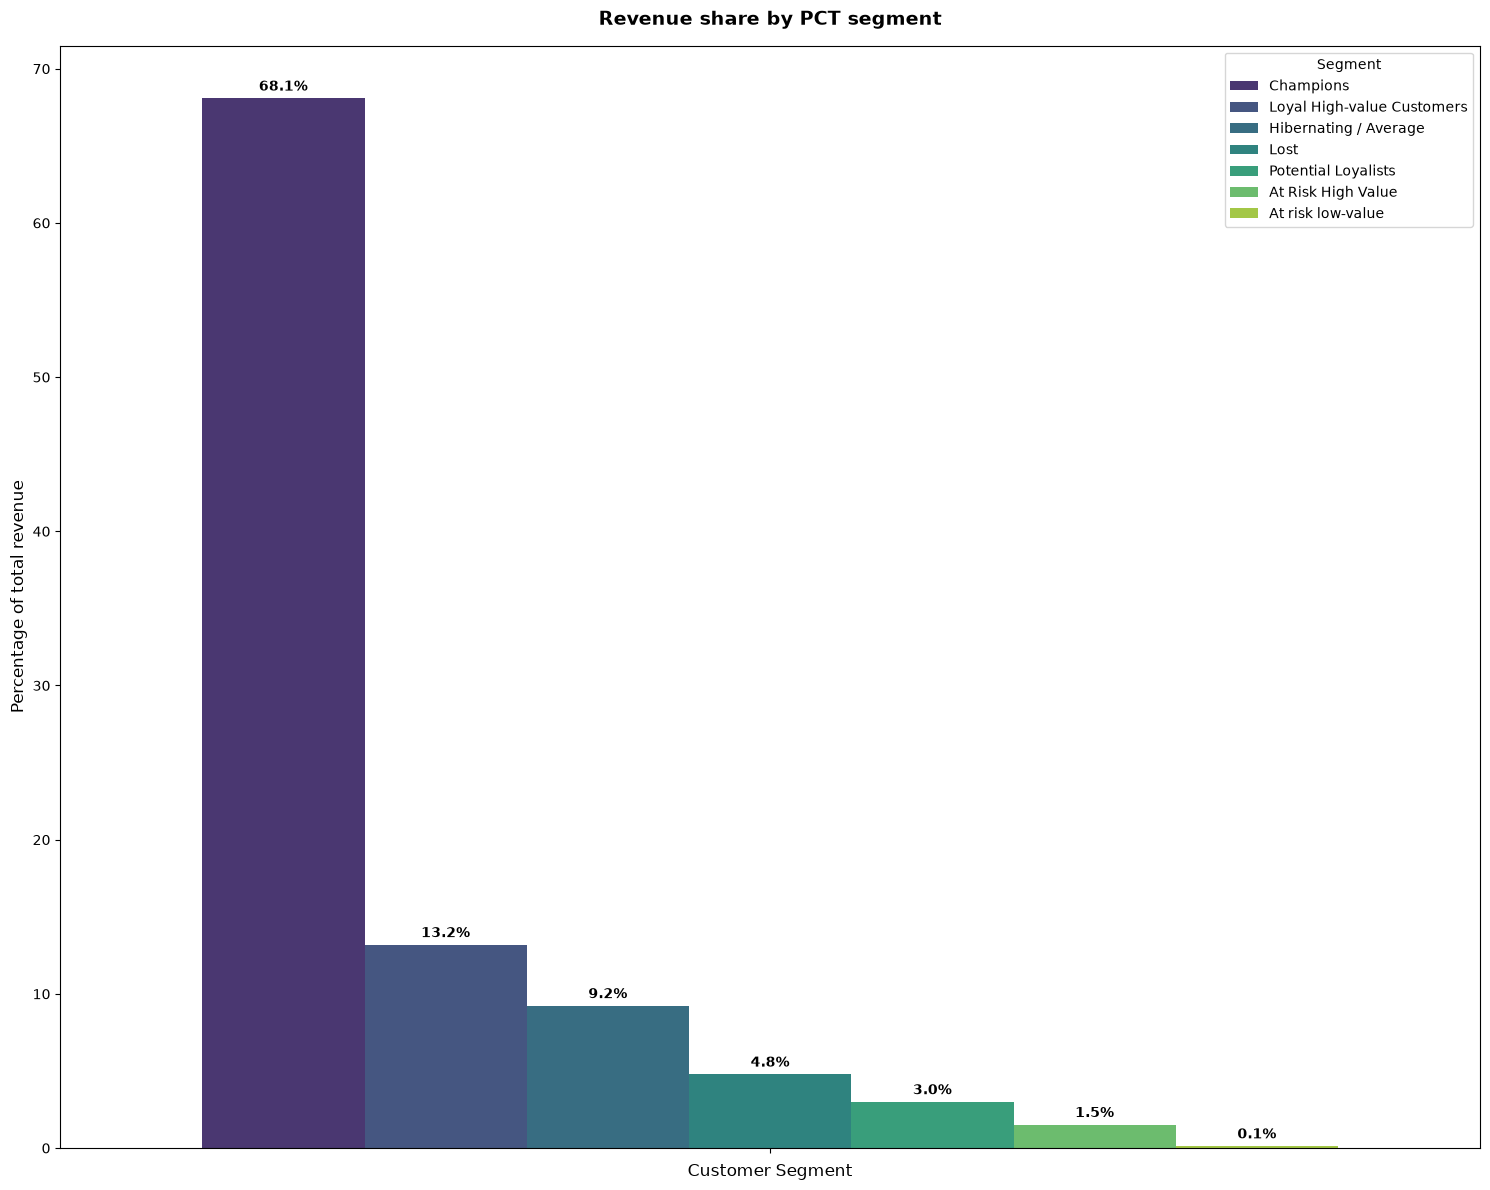

In [13]:
plt.figure(figsize=(15, 12))

sns.barplot(
    data=segment_summary,
    hue='Segment',
    y='Revenue_Pct',
    palette='viridis',
)


plt.title('Revenue share by PCT segment', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Percentage of total revenue', fontsize=12)

plt.tick_params(axis='x', labelrotation=45)

ax = plt.gca() 
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold')

plt.tight_layout() 
plt.show()


## Paraeto Analysis

In [14]:
# 3. Pareto Principle (80/20 Rule) Analysis
rfm_sorted = rfm.sort_values(by='Monetary', ascending=False).reset_index(drop=True)
rfm_sorted['Cum_Revenue'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['Cum_Rev_Pct'] = (rfm_sorted['Cum_Revenue'] / total_rev) * 100
rfm_sorted['Cum_Cust_Pct'] = ((rfm_sorted.index + 1) / total_cust) * 100

# Top 20% Customers Revenue Contribution
top_20_pct_idx = int(np.ceil(0.20 * total_cust))
top_20_rev_pct = rfm_sorted.loc[top_20_pct_idx - 1, 'Cum_Rev_Pct']

# How many top customers account for 80% of total revenue?
cust_for_80_rev = rfm_sorted[rfm_sorted['Cum_Rev_Pct'] >= 80].index[0] + 1
cust_pct_for_80_rev = (cust_for_80_rev / total_cust) * 100

print("\n=== Pareto Analysis Results ===")
print(f"Total Unique Customers: {total_cust}")
print(f"Total Revenue: ${total_rev:,.2f}")
print(f"Top 20% Customers ({top_20_pct_idx} customers) generate: {top_20_rev_pct:.2f}% of total revenue")
print(f"Top {cust_pct_for_80_rev:.2f}% of customers ({cust_for_80_rev} customers) account for 80.0% of total revenue")


=== Pareto Analysis Results ===
Total Unique Customers: 4372
Total Revenue: $8,300,065.81
Top 20% Customers (875 customers) generate: 73.85% of total revenue
Top 26.78% of customers (1171 customers) account for 80.0% of total revenue


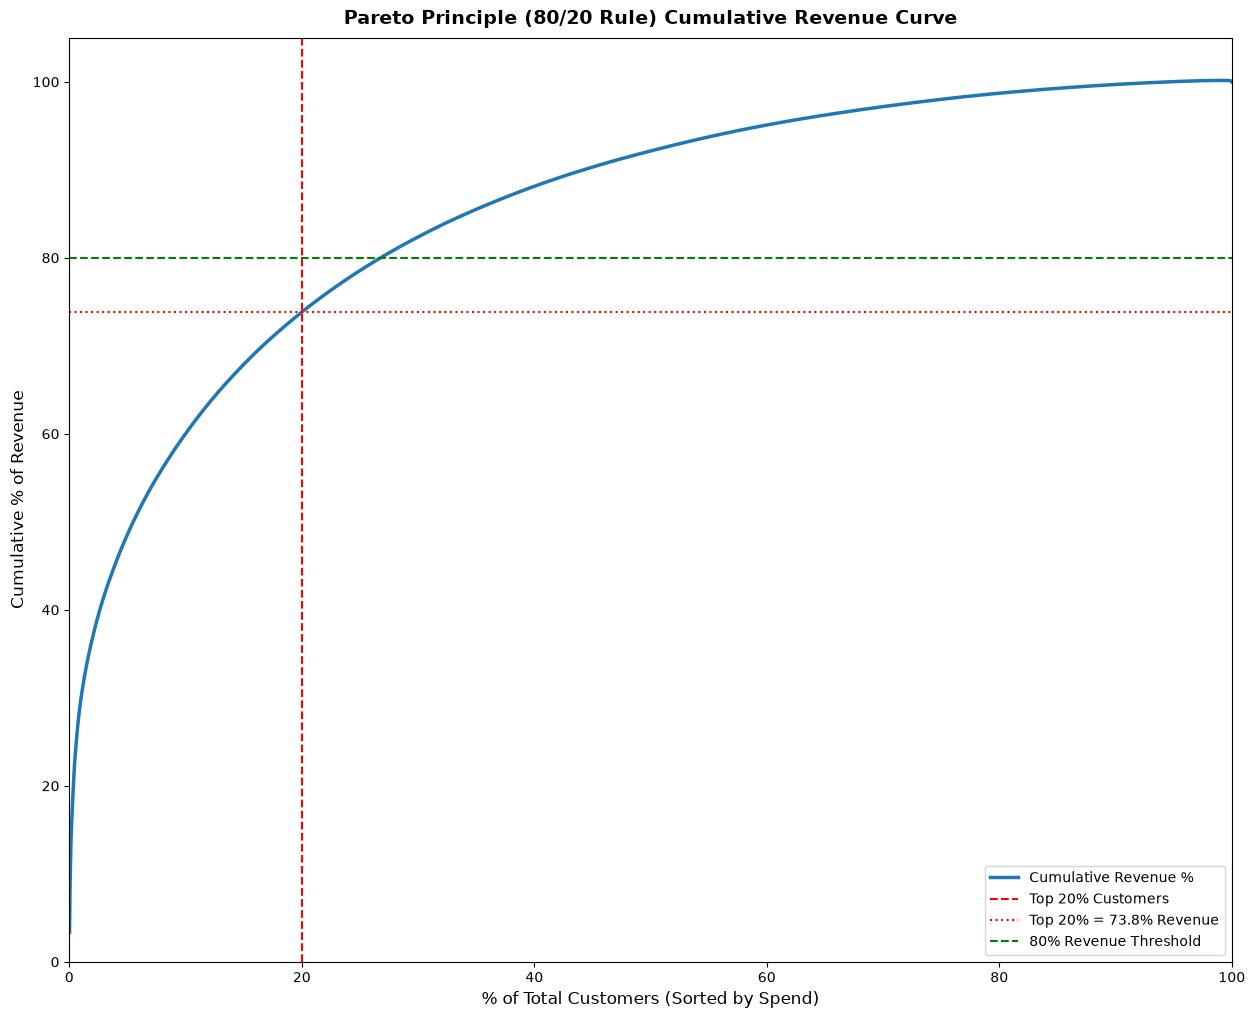

In [15]:
plt.figure(figsize=(15,12))

plt.plot(rfm_sorted['Cum_Cust_Pct'], rfm_sorted['Cum_Rev_Pct'], color='#1f77b4', linewidth=2.5, label='Cumulative Revenue %')
plt.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='Top 20% Customers')
plt.axhline(y=top_20_rev_pct, color='red', linestyle=':', linewidth=1.5, label=f'Top 20% = {top_20_rev_pct:.1f}% Revenue')
plt.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label=f'80% Revenue Threshold')

plt.title('Pareto Principle (80/20 Rule) Cumulative Revenue Curve', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('% of Total Customers (Sorted by Spend)', fontsize=12)
plt.ylabel('Cumulative % of Revenue', fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.legend(loc='lower right', frameon=True)

plt.show()

# Machine Model Building

In [16]:
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

## Churn Prediction

A customer is classified as churned if they make no purchase during the
90-day period following the observation date.

The model uses only information available before the observation date to
predict whether the customer will become inactive during the following
90 days.

Therefore, the model estimates 90-day customer inactivity risk rather than
permanent customer loss.

In [17]:
min_date = df['InvoiceDate'].min()
max_date = df['InvoiceDate'].max()

prediction_window = pd.Timedelta(days=90)

# Monthly observation dates.
# Stop 90 days before the end of the dataset so that every snapshot
# has a complete 90-day future period for the churn label.
observation_dates = pd.date_range(
    start=min_date + prediction_window,
    end=max_date - prediction_window,
    freq='MS'
)

print("Number of observation dates:", len(observation_dates))
print("Observation period:", min_date.date(), "to", max_date.date())

Number of observation dates: 7
Observation period: 2010-12-01 to 2011-12-09


In [19]:
#Creating Snapshots
def create_customer_snapshot(df, observation_date, prediction_days=90):
    
    observation_date = pd.Timestamp(observation_date)
    prediction_end = observation_date + pd.Timedelta(days=prediction_days)

    #Data prior to the observation date
    history = df[
        df['InvoiceDate'] <= observation_date
    ].copy()

    # Only positive quantities are treated as purchases
    sales_history = history[
        history['Quantity'] > 0
    ].copy()

    #future label for churn, we are trying to predict within 90 days of the observation date
    future = df[
        (df['InvoiceDate'] > observation_date) &
        (df['InvoiceDate'] <= prediction_end)
    ].copy()

    future_sales = future[
        future['Quantity'] > 0
    ].copy()

    #Active Customers by prediction day
    customer_ids = sales_history['CustomerID'].unique()

    features = (
        sales_history
        .groupby('CustomerID')
        .agg(
            Recency=(
                'InvoiceDate',
                lambda x: (observation_date - x.max()).days
            ),
            Frequency=(
                'InvoiceNo',
                'nunique'
            ),
            Monetary=(
                'TransactionValue',
                'sum'
            ),
            AvgBasketSize=(
                'Quantity',
                'mean'
            ),
            UniqueProducts=(
                'StockCode',
                'nunique'
            )
        )
        .reindex(customer_ids)
        .reset_index()
    )
    # Average value per actual order
    order_values = (
        sales_history
        .groupby(['CustomerID', 'InvoiceNo'])['TransactionValue']
        .sum()
        .groupby('CustomerID')
        .mean()
        .rename('AvgOrderValue')
        .reset_index()
    )
    
    features = features.merge(
        order_values,
        on='CustomerID',
        how='left'
    )

    #Recent 30 days activity
    last_30_start = observation_date - pd.Timedelta(days=30)

    recent_30 = sales_history[
        sales_history['InvoiceDate'] > last_30_start]

    recent_features = (
        recent_30
        .groupby('CustomerID')
        .agg(
            OrdersLast30Days=('InvoiceNo', 'nunique'),
            SpendLast30Days=('TransactionValue', 'sum'),
            QuantityLast30Days=('Quantity', 'sum')
        )
        .reset_index()
    )

    features = features.merge(
        recent_features,
        on='CustomerID',
        how='left'
    )

    #Previous 30 day activity
    previous_30_start = observation_date - pd.Timedelta(days=60)

    previous_30 = sales_history[
        (sales_history['InvoiceDate'] > previous_30_start) &
        (sales_history['InvoiceDate'] <= last_30_start)
    ]

    previous_features = (
        previous_30
        .groupby('CustomerID')
        .agg(
            OrdersPrevious30Days=('InvoiceNo', 'nunique'),
            SpendPrevious30Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

    features = features.merge(
        previous_features,
        on='CustomerID',
        how='left'
    )

    
    # Spend change
    features['SpendChange'] = np.where(
        features['SpendPrevious30Days'] > 0,
        (
            features['SpendLast30Days'] /
            features['SpendPrevious30Days']
        ),
        np.nan
    )

    
    # Order interval features
    sorted_sales = sales_history.sort_values(
        ['CustomerID', 'InvoiceDate']
    ).copy()

    sorted_sales['PreviousOrderDate'] = (
        sorted_sales
        .groupby('CustomerID')['InvoiceDate']
        .shift(1)
    )

    sorted_sales['DaysBetweenOrders'] = (
        sorted_sales['InvoiceDate']
        - sorted_sales['PreviousOrderDate']
    ).dt.days

    interval_features = (
        sorted_sales
        .groupby('CustomerID')['DaysBetweenOrders']
        .agg(
            AvgDaysBetweenOrders='mean',
            StdDaysBetweenOrders='std'
        )
        .reset_index()
    )

    features = features.merge(
        interval_features,
        on='CustomerID',
        how='left'
    )

    # Return behaviour
    returns_history = history[
        history['Quantity'] < 0
    ].copy()

    return_features = (
        returns_history
        .groupby('CustomerID')
        .agg(
            ReturnCount=('InvoiceNo', 'nunique'),
            ReturnedQuantity=('Quantity', lambda x: x.abs().sum()),
            ReturnedValue=(
                'TransactionValue',
                lambda x: x.abs().sum()
            )
        )
        .reset_index()
    )

    features = features.merge(
        return_features,
        on='CustomerID',
        how='left'
    )

    # Fill return/activity features
    zero_fill = [
        'OrdersLast30Days',
        'SpendLast30Days',
        'QuantityLast30Days',
        'OrdersPrevious30Days',
        'SpendPrevious30Days',
        'ReturnCount',
        'ReturnedQuantity',
        'ReturnedValue'
    ]

    features[zero_fill] = (
        features[zero_fill]
        .fillna(0)
    )

    # Return rate
    purchase_quantity = (
    sales_history
    .groupby('CustomerID')['Quantity']
    .sum()
    .rename('PurchasedQuantity')
    .reset_index()
    )
    
    features = features.merge(
        purchase_quantity,
        on='CustomerID',
        how='left'
    )
    
    features['ReturnRate'] = np.where(
        features['PurchasedQuantity'] > 0,
        features['ReturnedQuantity'] / features['PurchasedQuantity'],
        0
    )
    

    # Churn label
    future_customers = set(
        future_sales['CustomerID'].unique()
    )

    features['Churn'] = (
        ~features['CustomerID']
        .isin(future_customers)
    ).astype(int)

    # Snapshot date
    features['ObservationDate'] = observation_date

    return features

In [20]:
# BUILD MULTIPLE SNAPSHOTS

snapshot_list = []

for date in observation_dates:
    
    snapshot = create_customer_snapshot(
        df=df,
        observation_date=date,
        prediction_days=90
    )
    
    snapshot_list.append(snapshot)

model_data = pd.concat(
    snapshot_list,
    ignore_index=True
)

print("Model dataset shape:", model_data.shape)
display(model_data.head())

Model dataset shape: (18393, 22)


,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,UniqueProducts,AvgOrderValue,OrdersLast30Days,SpendLast30Days,QuantityLast30Days,...,SpendChange,AvgDaysBetweenOrders,StdDaysBetweenOrders,ReturnCount,ReturnedQuantity,ReturnedValue,PurchasedQuantity,ReturnRate,Churn,ObservationDate
0,17850.0,88,34,5391.21,5.835017,21,158.5650,0.0,0.00,0.0,...,NaN,0.000000,0.000000,1.0,40.0,102.58,1733,0.023081,1,2011-03-01 08:26:00
1,13047.0,25,4,825.53,7.255814,34,206.3825,1.0,458.90,211.0,...,NaN,1.523810,9.875414,1.0,1.0,2.95,312,0.003205,0,2011-03-01 08:26:00
2,12583.0,18,3,1907.58,25.345455,42,635.8600,1.0,321.56,454.0,...,0.440397,1.314815,6.773489,1.0,1.0,18.00,1394,0.000717,0,2011-03-01 08:26:00
3,13748.0,89,1,204.00,80.000000,1,204.0000,0.0,0.00,0.0,...,NaN,NaN,NaN,0.0,0.0,0.00,80,0.000000,0,2011-03-01 08:26:00
4,15100.0,49,3,876.00,26.666667,1,292.0000,0.0,0.00,0.0,...,NaN,19.500000,17.677670,3.0,22.0,240.90,80,0.275000,1,2011-03-01 08:26:00


In [21]:
# CHURN DISTRIBUTION

churn_distribution = (
    model_data['Churn']
    .value_counts(normalize=True)
    .sort_index()
)

print("Churn distribution:")
display(churn_distribution)

print("\nNumber of observations:")
display(
    model_data['Churn']
    .value_counts()
)

Churn distribution:


Churn
0    0.528679
1    0.471321
Name: proportion, dtype: float64


Number of observations:


Churn
0    9724
1    8669
Name: count, dtype: int64

In [22]:
# REMOVE CUSTOMERS WITH TOO LITTLE HISTORY

model_data = model_data[
    model_data['Frequency'] >= 2
].copy()

print("Shape after minimum-history filter:", model_data.shape)

Shape after minimum-history filter: (9386, 22)


In [23]:
# HANDLE MISSING INTERVAL FEATURES


model_data['AvgDaysBetweenOrders'] = (
    model_data['AvgDaysBetweenOrders']
    .fillna(model_data['Recency'])
)

model_data['StdDaysBetweenOrders'] = (
    model_data['StdDaysBetweenOrders']
    .fillna(0)
)

In [24]:
# TEMPORAL TRAIN / TEST SPLIT

model_data = model_data.sort_values(
    'ObservationDate'
).reset_index(drop=True)

unique_dates = sorted(
    model_data['ObservationDate'].unique()
)

split_date = unique_dates[
    int(len(unique_dates) * 0.75)
]

train_data = model_data[
    model_data['ObservationDate'] < split_date
].copy()

test_data = model_data[
    model_data['ObservationDate'] >= split_date
].copy()

print("Training period:")
print(
    train_data['ObservationDate'].min(),
    "to",
    train_data['ObservationDate'].max()
)

print("\nTesting period:")
print(
    test_data['ObservationDate'].min(),
    "to",
    test_data['ObservationDate'].max()
)

print("\nTrain shape:", train_data.shape)
print("Test shape:", test_data.shape)

Training period:
2011-03-01 08:26:00 to 2011-07-01 08:26:00

Testing period:
2011-08-01 08:26:00 to 2011-09-01 08:26:00

Train shape: (5649, 22)
Test shape: (3737, 22)


In [25]:
# FEATURES AND TARGET

drop_columns = [
    'CustomerID',
    'ObservationDate',
    'Churn'
]

X_train = train_data.drop(
    columns=drop_columns
)

y_train = train_data['Churn']

X_test = test_data.drop(
    columns=drop_columns
)

y_test = test_data['Churn']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5649, 19)
X_test: (3737, 19)
y_train: (5649,)
y_test: (3737,)


In [26]:
# RECENCY-ONLY BASELINE

baseline_model = LGBMClassifier(
    objective='binary',
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=15,
    random_state=42,
    verbosity=-1
)

baseline_model.fit(
    X_train[['Recency']],
    y_train
)

baseline_probs = baseline_model.predict_proba(
    X_test[['Recency']]
)[:, 1]

baseline_auc = roc_auc_score(
    y_test,
    baseline_probs
)

baseline_pr_auc = average_precision_score(
    y_test,
    baseline_probs
)

print("Baseline ROC-AUC:", round(baseline_auc, 4))
print("Baseline PR-AUC:", round(baseline_pr_auc, 4))

Baseline ROC-AUC: 0.6472
Baseline PR-AUC: 0.4683


In [27]:
# LIGHTGBM CHURN MODEL

model = LGBMClassifier(
    objective='binary',
    learning_rate=0.02,
    n_estimators=300,
    num_leaves=31,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train,
    y_train
)

,learning_rate,0.02
,n_estimators,300
,objective,'binary'
,reg_alpha,0.1
,reg_lambda,0.1
,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000


In [28]:
# PREDICTIONS

test_probs = model.predict_proba(
    X_test
)[:, 1]

test_preds = (
    test_probs >= 0.5
).astype(int)

In [29]:
# MODEL EVALUATION

roc_auc = roc_auc_score(
    y_test,
    test_probs
)

pr_auc = average_precision_score(
    y_test,
    test_probs
)

precision = precision_score(
    y_test,
    test_preds,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_preds,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_preds,
    zero_division=0
)

print("ROC-AUC :", round(roc_auc, 4))
print("PR-AUC  :", round(pr_auc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_preds,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_preds
    )
)

ROC-AUC : 0.7759
PR-AUC  : 0.5925
Precision: 0.585
Recall   : 0.5405
F1-score : 0.5619

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81      2553
           1       0.59      0.54      0.56      1184

    accuracy                           0.73      3737
   macro avg       0.69      0.68      0.68      3737
weighted avg       0.73      0.73      0.73      3737


Confusion Matrix:
[[2099  454]
 [ 544  640]]


In [30]:
# BASELINE VS FULL MODEL


comparison = pd.DataFrame({
    'Model': [
        'Recency Baseline',
        'Full LightGBM'
    ],
    'ROC_AUC': [
        baseline_auc,
        roc_auc
    ],
    'PR_AUC': [
        baseline_pr_auc,
        pr_auc
    ]
})

display(
    comparison.round(4)
)

,Model,ROC_AUC,PR_AUC
0,Recency Baseline,0.6472,0.4683
1,Full LightGBM,0.7759,0.5925


In [31]:
# TOP 10% CHURN TARGETING


evaluation = test_data[
    ['CustomerID', 'ObservationDate', 'Churn']
].copy()

evaluation['ChurnProbability'] = test_probs

evaluation = evaluation.sort_values(
    'ChurnProbability',
    ascending=False
)

top_10_percent = int(
    np.ceil(len(evaluation) * 0.10)
)

top_customers = evaluation.head(
    top_10_percent
)

recall_at_10 = (
    top_customers['Churn'].sum()
    / evaluation['Churn'].sum()
)

print(
    "Recall@10%:",
    round(recall_at_10, 4)
)

Recall@10%: 0.2179


In [32]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

display(
    feature_importance
)

,Feature,Importance
3,AvgBasketSize,1020
13,StdDaysBetweenOrders,946
17,PurchasedQuantity,884
5,AvgOrderValue,794
12,AvgDaysBetweenOrders,753
4,UniqueProducts,742
2,Monetary,646
18,ReturnRate,641
0,Recency,615
16,ReturnedValue,524


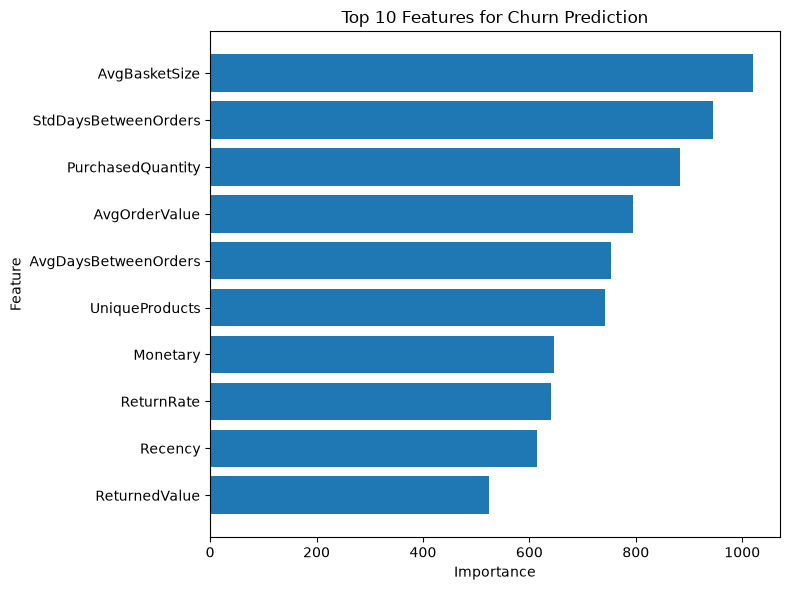

In [33]:
plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance['Feature'].head(10)[::-1],
    feature_importance['Importance'].head(10)[::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features for Churn Prediction')

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok =True)
joblib.dump(
    final_model,
    "../models/churn_model.pkl"
)

joblib.dump(
    X_train.columns.to_list(),
    "../models/feature_columns.pkl"
)
print("Model saved Successfully")

In [2]:
!uv pip install streamlit app


Using Python 3.14.4 environment at: /home/qheerah/my_env
Resolved 37 packages in 7.58s                                        
Prepared 1 package in 1m 35s                                             
Installed 12 packages in 144ms                              
 + altair==6.2.2
 + app==0.0.1
 + httptools==0.8.0
 + itsdangerous==2.2.0
 + protobuf==7.36.1
 + pyarrow==25.0.1
 + pydeck==0.9.3
 + python-multipart==0.0.32
 + streamlit==1.63.0
 + toml==0.10.2
 + watchdog==6.0.0
 + websockets==16.1.1
